<a href="https://colab.research.google.com/github/Siddhesh-2028/CrashCrew/blob/main/Solar_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
data=pd.read_csv('Generation_data.csv')
data.head()

,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
0,18.7675,17.85190,47.60506,6.388252,0.60,8.6,8.6,8.7,3233
1,18.6150,18.59573,64.26684,12.776500,0.66,9.6,9.7,10.0,4504
2,18.9200,18.59573,85.68912,17.035340,4.74,11.9,12.0,12.4,6614
3,18.9200,18.59573,83.30886,25.553010,8.18,14.8,14.7,14.7,8971
4,19.0725,18.59573,57.12608,36.200090,26.66,18.6,18.4,18.5,12071


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118865 entries, 0 to 118864
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   MODULE_TEMP         118865 non-null  float64
 1   Amb_Temp            118865 non-null  float64
 2   WIND_Speed          118865 non-null  float64
 3   IRR (W/m2)          118865 non-null  float64
 4   DC Current in Amps  118865 non-null  float64
 5   AC Ir in Amps       118865 non-null  float64
 6   AC Iy in Amps       118865 non-null  float64
 7   AC Ib in Amps       118865 non-null  float64
 8   AC Power in Watts   118865 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 8.2 MB


In [62]:
data.describe()

,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
count,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000
mean,37.141972,22.961983,224.429052,428.093276,355.902071,172.329754,172.190557,172.351243,128081.179666
std,12.017936,3.921594,230.238430,313.280827,264.863384,120.507508,120.448101,120.503308,91193.677193
min,8.855000,10.413610,0.238025,2.129417,0.600000,1.400000,1.400000,1.500000,394.000000
25%,26.697500,20.083390,28.325010,155.447500,126.180000,65.600000,65.500000,65.600000,47737.000000
50%,36.457500,23.058700,59.030280,357.742100,298.600000,150.000000,150.000000,150.100000,110673.000000
75%,46.675000,26.034020,442.727100,687.801800,576.320000,277.700000,277.400000,277.600000,206594.000000
max,72.447500,34.959970,597.443500,1494.851000,995.679988,461.200000,461.100000,461.700000,332614.000000


<Axes: >

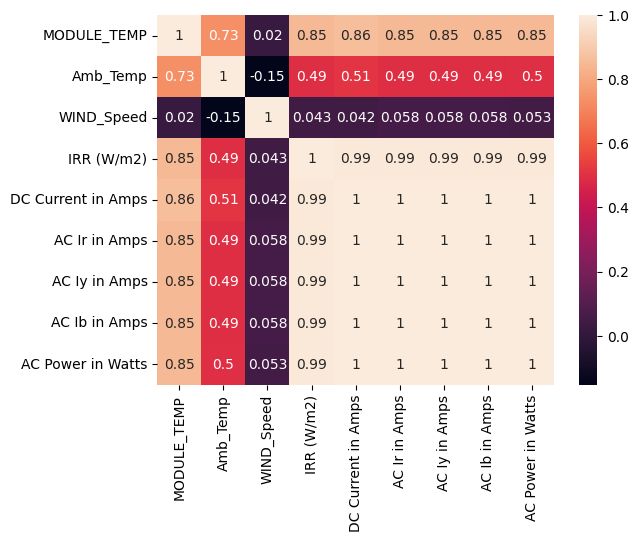

In [63]:
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='MODULE_TEMP', ylabel='Amb_Temp'>

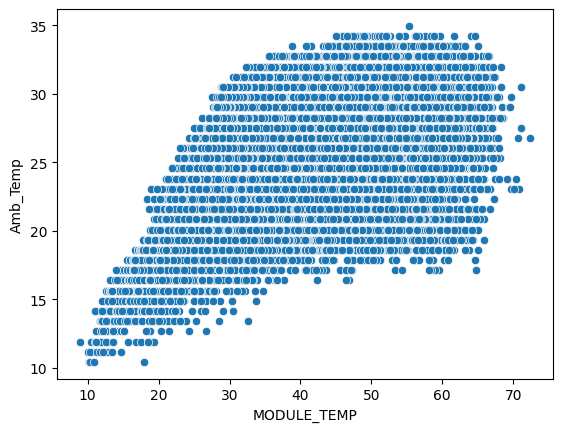

In [64]:
sns.scatterplot(data=data,x='MODULE_TEMP',y='Amb_Temp')

<Axes: xlabel='MODULE_TEMP', ylabel='DC Current in Amps'>

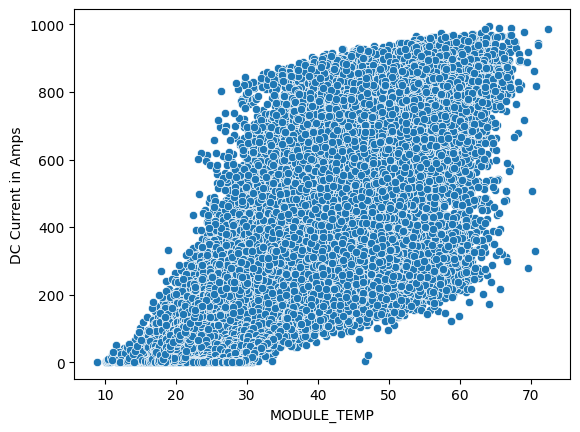

In [65]:
sns.scatterplot(data=data,x='MODULE_TEMP',y='DC Current in Amps')

<Axes: xlabel='MODULE_TEMP', ylabel='AC Power in Watts'>

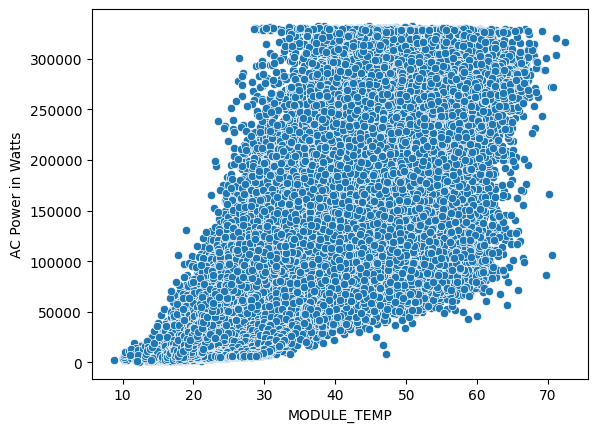

In [66]:
sns.scatterplot(data=data,x='MODULE_TEMP',y='AC Power in Watts')

<Axes: xlabel='IRR (W/m2)', ylabel='AC Power in Watts'>

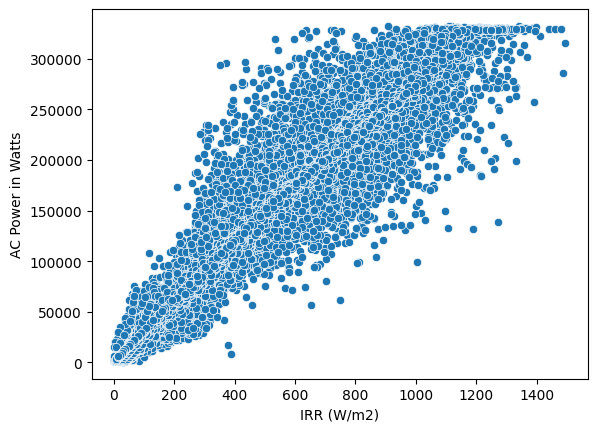

In [67]:
sns.scatterplot(data=data,x='IRR (W/m2)',y='AC Power in Watts')

<Axes: xlabel='WIND_Speed', ylabel='AC Power in Watts'>

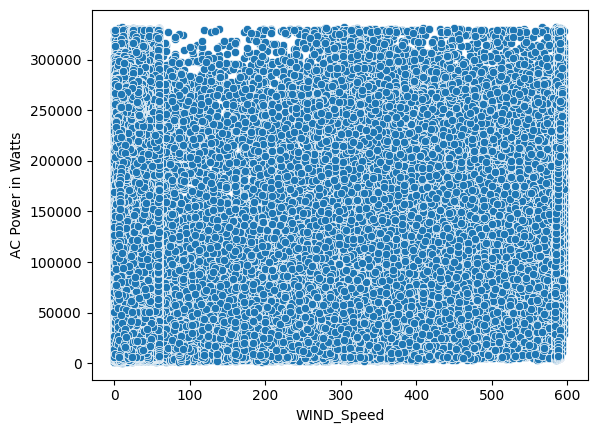

In [68]:
sns.scatterplot(data=data,x='WIND_Speed',y='AC Power in Watts')

<Axes: xlabel='MODULE_TEMP', ylabel='Count'>

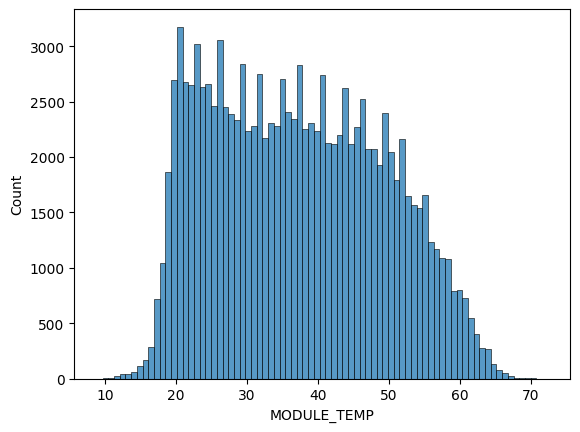

In [69]:
sns.histplot(data=data['MODULE_TEMP'])

<Axes: xlabel='Amb_Temp', ylabel='Count'>

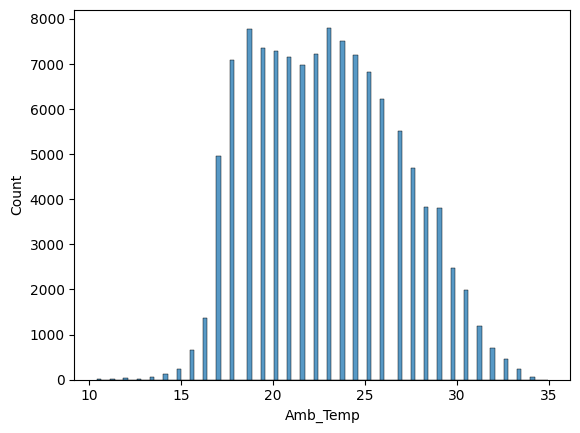

In [70]:
sns.histplot(data=data['Amb_Temp'])

In [71]:
x=data.loc[:,'Amb_Temp':'AC Ib in Amps']
y=data.loc[:,('MODULE_TEMP','AC Power in Watts')]

In [72]:
from sklearn.preprocessing import StandardScaler
sc1=StandardScaler()
sc2=StandardScaler()
x=sc1.fit_transform(x)
y=sc2.fit_transform(y)

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [74]:
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor(random_state=0)
model_rf.fit(x_train,y_train)


RandomForestRegressor(random_state=0)

In [75]:
y_pred_rf=model_rf.predict(x_test)

In [76]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred_rf))
print(root_mean_squared_error(y_test,y_pred_rf))
print(mean_absolute_error(y_test,y_pred_rf))

0.9587766072250519
0.15668570444407814
0.11039480533653989


In [77]:
y_pred=sc2.inverse_transform(y_pred_rf)


In [78]:
y_pred=pd.DataFrame(y_pred,columns=['MODULE_TEMP','AC Power in Watts'])
y_pred.head()

,MODULE_TEMP,AC Power in Watts
0,33.842124,125873.12
1,44.160273,273379.74
2,16.318347,17567.44
3,42.757273,170590.61
4,42.592574,96477.61


In [87]:
y_test=sc2.inverse_transform(y_test)
y_test=pd.DataFrame(y_test,columns=['MODULE_TEMP_actual','AC Power in Watts_actual'])
y_test.head()

,MODULE_TEMP_actual,AC Power in Watts_actual
0,453.291313,1.145382e+10
1,561.422121,2.518863e+10
2,213.203999,1.625284e+09
3,552.258603,1.542383e+10
4,522.934841,8.708267e+09


In [88]:
result=pd.concat([y_test,y_pred],axis=1)
result.head()

,MODULE_TEMP_actual,AC Power in Watts_actual,MODULE_TEMP,AC Power in Watts
0,453.291313,1.145382e+10,33.842124,125873.12
1,561.422121,2.518863e+10,44.160273,273379.74
2,213.203999,1.625284e+09,16.318347,17567.44
3,552.258603,1.542383e+10,42.757273,170590.61
4,522.934841,8.708267e+09,42.592574,96477.61


<Axes: xlabel='MODULE_TEMP_actual', ylabel='MODULE_TEMP'>

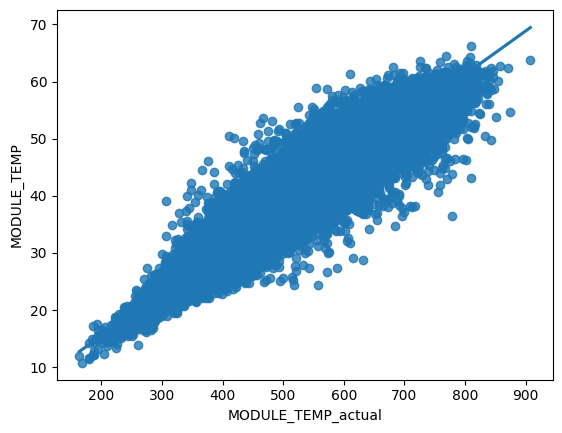

In [93]:
sns.regplot(data=result,x='MODULE_TEMP_actual',y='MODULE_TEMP')

<Axes: xlabel='AC Power in Watts_actual', ylabel='AC Power in Watts'>

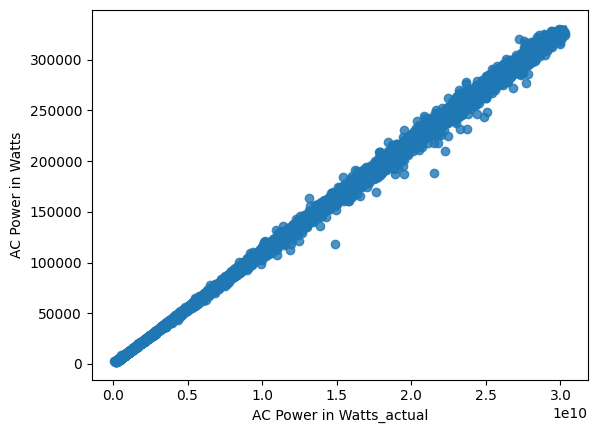

In [94]:
sns.regplot(data=result,x='AC Power in Watts_actual',y='AC Power in Watts')

In [80]:
x_test_original_scale = sc1.inverse_transform(x_test)

x_columns = data.loc[:,'Amb_Temp':'AC Ib in Amps'].columns
x_test_df = pd.DataFrame(x_test_original_scale, columns=x_columns)

merged_predictions = pd.concat([x_test_df, y_pred], axis=1)
merged_predictions.head()

,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,MODULE_TEMP,AC Power in Watts
0,17.85190,585.54230,436.53050,342.88,169.8,169.8,169.9,33.842124,125873.12
1,22.31487,587.92250,900.74350,762.54,370.7,370.7,370.6,44.160273,273379.74
2,14.87658,45.22481,78.78844,44.74,25.0,25.2,25.3,16.318347,17567.44
3,26.03402,22.61240,530.22490,471.66,229.2,230.3,230.4,42.757273,170590.61
4,29.75317,595.06330,313.02430,264.68,129.7,129.7,130.5,42.592574,96477.61


MASS FLOW RATE:

In [104]:
dt=[]
for i in range(len(merged_predictions['MODULE_TEMP'])):
  t=merged_predictions.loc[i,'MODULE_TEMP']-25
  if t>0:
    dt.append(t)
  else:
    dt.append(0)
Q=[]
for k in dt:
  q=1000*1*3.6*k
  Q.append(q)
mfr=[]
for j in Q:
  m=j/(4.186*15)
  mfr.append(m)

Mass_Flow_Rate=pd.DataFrame(mfr,columns=['Mass Flow Rate'])
Mass_Flow_Rate.head(10)


,Mass Flow Rate
0,506.954070
1,1098.534525
2,0.000000
3,1018.094976
4,1008.652105
5,216.147446
6,715.572189
7,1572.253600
8,1878.623283
9,0.000000


In [107]:
mfr_result=pd.DataFrame({'MODULE_TEMP':merged_predictions['MODULE_TEMP'],'Mass Flow Rate':Mass_Flow_Rate['Mass Flow Rate']})
mfr_result.head()

,MODULE_TEMP,Mass Flow Rate
0,33.842124,506.954070
1,44.160273,1098.534525
2,16.318347,0.000000
3,42.757273,1018.094976
4,42.592574,1008.652105


<Axes: xlabel='MODULE_TEMP', ylabel='Mass Flow Rate'>

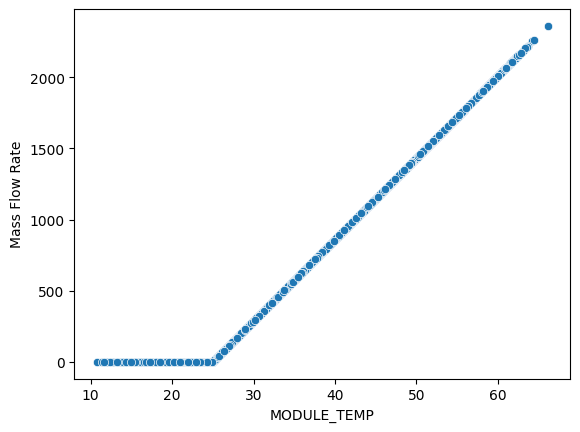

In [110]:
sns.scatterplot(data=mfr_result,x='MODULE_TEMP',y='Mass Flow Rate')